# Analisi dei dati con Pandas

In [1]:
import pandas as pd
import numpy as np
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sns

### Caricamento dataset pulito

In [2]:
dfHotelClean = pd.read_csv("hotel_reviews_clean.csv")

Dopo l'importazione del file CSV, viene effettuato un controllo sul tipo della colonna review_date per verificare se i valori sono stati interpretati correttamente. Nel caso in cui la colonna risulti di tipo stringa, si procede alla conversione in formato datetime, in modo da garantire una gestione coerente e corretta delle informazioni temporali nelle successive elaborazioni.

In [3]:
print(dfHotelClean["review_date"].dtypes)

str


In [4]:
dfHotelClean["review_date"] = pd.to_datetime(dfHotelClean["review_date"])
print(dfHotelClean["review_date"].dtypes)

datetime64[us]


# Riproduzione Query SQL
In questa sezione andiamo a riprodurre le analisi principali effettuate precedentemente in SQL utilizzando la libreria Pandas. 
L'obiettivo è quello di verificare che il processo di pulizia e i calcoli siano coerenti tra i due strumenti.

## Analisi 1: Recensioni nel tempo

### Andamento recensioni mese e anno
In questa sezione viene analizzato l’andamento delle recensioni nel tempo, con l’obiettivo di osservare come il numero e la qualità delle valutazioni varino su base mensile e annuale. In particolare, si procede al calcolo del totale delle recensioni, del punteggio minimo, massimo e medio per ciascuna combinazione di anno e mese.
Per motivi di leggibilità, nelle diverse sezioni verranno riportati esclusivamente estratti rappresentativi delle tabelle risultanti, mentre gli interi dataset aggregati saranno utilizzati per la realizzazione delle visualizzazioni grafiche e delle analisi successive.

In [5]:
andamento_temporale = dfHotelClean.groupby(["year", "month"])["reviewer_score"].agg(["count", "min", "max", "mean"]).reset_index()
andamento_temporale.columns = ["anno", "mese", "totale_recensioni", "punteggio_minimo", "punteggio_massimo", "punteggio_medio"]
andamento_temporale = andamento_temporale.sort_values(by=["anno", "mese"])
andamento_temporale["punteggio_medio"] = andamento_temporale["punteggio_medio"].round(3)
print(andamento_temporale.head(10))

   anno  mese  totale_recensioni  punteggio_minimo  punteggio_massimo  \
0  2015     8              19142               2.5               10.0   
1  2015     9              19554               2.5               10.0   
2  2015    10              19309               2.5               10.0   
3  2015    11              17930               2.5               10.0   
4  2015    12              17777               2.5               10.0   
5  2016     1              19343               2.5               10.0   
6  2016     2              18767               2.5               10.0   
7  2016     3              20619               2.5               10.0   
8  2016     4              21354               2.5               10.0   
9  2016     5              22921               2.5               10.0   

   punteggio_medio  
0            8.379  
1            8.255  
2            8.195  
3            8.316  
4            8.465  
5            8.522  
6            8.547  
7            8.519  
8      

### Hotel con picco recensioni
In questa analisi viene identificata la combinazione hotel–anno–mese che registra il maggior numero di recensioni, al fine di evidenziare il picco assoluto di attività e individuare il mese in cui si verifica il massimo volume di valutazioni.

L’elaborazione viene effettuata raggruppando i dati per hotel e per combinazione di anno e mese, calcolando il numero totale di recensioni per ciascun gruppo e ordinando i risultati in modo decrescente rispetto al volume di recensioni mensili.

In [6]:
hotel_picco_recensioni = dfHotelClean.groupby(["hotel_name", "year", "month"]).size().reset_index(name="recensioni_mensili")
hotel_picco_recensioni = hotel_picco_recensioni.sort_values(by="recensioni_mensili", ascending=False)
print(hotel_picco_recensioni.head(1))

                hotel_name  year  month  recensioni_mensili
28442  Strand Palace Hotel  2016      2                 304


## Analisi 2: Nazionalità recensori

### Top 10 nazionalità per numero recensioni e score medio
In questa analisi vengono individuate le dieci nazionalità dei recensori con il maggior numero di recensioni, calcolando contestualmente il punteggio medio assegnato. L’obiettivo è evidenziare sia la provenienza più attiva in termini di contributi, sia l’eventuale differenza nella valutazione media espressa.

L’elaborazione viene effettuata raggruppando i dati per nazionalità del recensore e calcolando il numero totale di recensioni e il punteggio medio per ciascun gruppo, successivamente ordinati in ordine decrescente rispetto al volume di recensioni.

In [7]:
top_nazionalita = dfHotelClean.groupby("reviewer_nationality")["reviewer_score"].agg(["count", "mean"]).reset_index()
top_nazionalita.columns = ["nazionalita", "numero_recensioni", "score_medio"]
top_nazionalita = top_nazionalita.sort_values(by="numero_recensioni", ascending=False)
top_nazionalita = top_nazionalita.head(10)
print(top_nazionalita)

                  nazionalita  numero_recensioni  score_medio
213            United Kingdom             244321     8.486302
215  United States of America              35108     8.788285
13                  Australia              21502     8.592229
97                    Ireland              14733     8.463056
212      United Arab Emirates              10170     7.882616
175              Saudi Arabia               8903     7.884938
143               Netherlands               8691     8.127062
196               Switzerland               8607     8.160892
77                    Germany               7831     8.133840
37                     Canada               7802     8.546180


### % contributo top nazionalità al totale recensioni
Viene calcolato il contributo percentuale delle principali nazionalità dei recensori rispetto al totale complessivo delle recensioni. L’obiettivo è evidenziare il peso relativo delle diverse provenienze in termini di partecipazione al dataset, mettendo in luce le nazionalità maggiormente rappresentative.

L’elaborazione viene effettuata calcolando il numero di recensioni per ciascuna nazionalità e rapportandolo al totale delle recensioni, così da ottenere la percentuale di contributo per ciascun gruppo. I risultati vengono poi ordinati in ordine decrescente e limitati alle prime dieci nazionalità.

In [8]:
totale_recensioni = len(dfHotelClean)
ranking_nazionalita = dfHotelClean.groupby("reviewer_nationality").size().reset_index(name="numero_recensioni")
ranking_nazionalita.columns = ["nazionalita", "numero_recensioni"]
ranking_nazionalita["percentuale_contributo"] = (ranking_nazionalita["numero_recensioni"]*100 / totale_recensioni).round(2)
ranking_nazionalita = ranking_nazionalita.sort_values(by="numero_recensioni", ascending=False).head(10)
print(ranking_nazionalita)


                  nazionalita  numero_recensioni  percentuale_contributo
213            United Kingdom             244321                   47.72
215  United States of America              35108                    6.86
13                  Australia              21502                    4.20
97                    Ireland              14733                    2.88
212      United Arab Emirates              10170                    1.99
175              Saudi Arabia               8903                    1.74
143               Netherlands               8691                    1.70
196               Switzerland               8607                    1.68
77                    Germany               7831                    1.53
37                     Canada               7802                    1.52


### Confronto score medio UK vs altri
Viene effettuato un confronto tra i recensori provenienti dal Regno Unito e quelli provenienti dagli altri paesi, con l’obiettivo di verificare eventuali differenze nel punteggio medio assegnato alle strutture.

Per semplificare il confronto, le nazionalità vengono riclassificate in due macro-categorie (“UK” e “altri”), successivamente utilizzate per aggregare il numero di recensioni e il punteggio medio. Si evidenzia inoltre che il Regno Unito rappresenta la prima nazionalità per numero di recensioni all’interno della top 10 precedentemente calcolata.

L’analisi consente di evidenziare eventuali differenze nei comportamenti di valutazione tra i due gruppi.

In [9]:
categoria_provenienza = np.where(dfHotelClean["reviewer_nationality"] == "United Kingdom", "UK", "altri")
confronto_uk_altri = dfHotelClean.groupby(categoria_provenienza)["reviewer_score"].agg([
    ("numero_recensioni", "count"),
    ("punteggio_medio", "mean")
]).reset_index()
confronto_uk_altri.columns = ["caterogia_provenienza", "numero_recensioni", "punteggio_medio"]
print(confronto_uk_altri)

  caterogia_provenienza  numero_recensioni  punteggio_medio
0                    UK             244321         8.486302
1                 altri             267623         8.313662


## Analisi 3: Hotel e performance

### Hotel con maggior average_score e numero recensioni
Viene individuato l’hotel con il maggior valore di punteggio medio (average score), considerando contestualmente anche il numero totale di recensioni.

L’elaborazione viene effettuata selezionando le informazioni univoche per ciascun hotel ed ordinando i risultati in modo decrescente prima rispetto al punteggio medio e successivamente al numero totale di recensioni, così da privilegiare le strutture con performance elevate e un numero significativo di valutazioni.

In [10]:
colonne_hotel = ["hotel_name", "average_score", "total_number_of_reviews"]
df_hotels_unici = dfHotelClean[colonne_hotel]

df_hotels_unici = df_hotels_unici.drop_duplicates()

top_hotel = df_hotels_unici.sort_values(by=["average_score", "total_number_of_reviews"], ascending=[False, False])

top_hotel.head(1)

,hotel_name,average_score,total_number_of_reviews
54716,Ritz Paris,9.8,122


### Analisi gap tra reviewer_score e average_score
Si esamina la differenza tra il punteggio medio delle recensioni effettivamente presenti nel dataset (reviewer_score) e il punteggio medio ufficiale associato a ciascun hotel (average_score).

L’obiettivo è individuare eventuali discrepanze tra la percezione reale degli utenti e il valore sintetico attribuito alla struttura, evidenziando i casi in cui il punteggio medio delle recensioni risulta significativamente più alto o più basso rispetto allo score ufficiale.

L’elaborazione viene effettuata calcolando, per ciascun hotel, la media dei punteggi delle recensioni e confrontandola con il valore di average_score, determinando così il gap di punteggio e ordinando i risultati in base a tale differenza.

In [11]:
gap_analisi = dfHotelClean.groupby(["hotel_name", "average_score"])["reviewer_score"].mean().reset_index()
gap_analisi.columns = ["nome_hotel", "score_ufficiale", "media_recensioni_attuali"]

gap_analisi["gap_punteggio"] = (gap_analisi["media_recensioni_attuali"] - gap_analisi["score_ufficiale"]).round(2)
gap_analisi = gap_analisi.sort_values(by="gap_punteggio", ascending=False)

gap_analisi.head(10)

,nome_hotel,score_ufficiale,media_recensioni_attuali,gap_punteggio
130,Best Western Hotel Astoria,7.7,8.462162,0.76
991,Mercure Paris Porte d Orleans,7.5,8.180000,0.68
1184,Renaissance Paris Vendome Hotel,7.9,8.578571,0.68
757,Hotel Stendhal Place Vend me Paris MGallery by...,8.8,9.465517,0.67
607,Hotel De Vigny,7.5,8.042857,0.54
289,Drawing Hotel,8.9,9.414286,0.51
736,Hotel Royal Elys es,7.0,7.453333,0.45
1015,Monhotel Lounge SPA,8.4,8.848571,0.45
999,MiHotel,7.8,8.245455,0.45
666,Hotel Les Rives de Notre Dame,8.6,9.054167,0.45


## Analisi 4: Geografia

### Distribuzione recensioni per città
Si esamina la distribuzione delle recensioni tra le diverse città presenti nel dataset, con l’obiettivo di individuare le aree geografiche maggiormente rappresentate.

Per ciascuna città viene calcolato il numero totale di recensioni e la relativa percentuale sul totale complessivo, così da evidenziare il peso di ogni località all’interno del dataset. I risultati vengono successivamente ordinati in ordine decrescente rispetto al numero di recensioni, al fine di mettere in risalto le città con il maggiore volume di contributi.

In [12]:
totale_complessivo = len(dfHotelClean)

distribuzione_recensioni_per_citta = dfHotelClean.groupby("hotel_city").size().reset_index(name="numero_recensioni")
distribuzione_recensioni_per_citta.columns = ["citta",  "numero_recensioni"]

distribuzione_recensioni_per_citta["percentuale_sul_totale"] = (distribuzione_recensioni_per_citta["numero_recensioni"] * 100 / totale_complessivo).round(2)
distribuzione_recensioni_per_citta = distribuzione_recensioni_per_citta.sort_values(by="numero_recensioni", ascending=False)

distribuzione_recensioni_per_citta

,citta,numero_recensioni,percentuale_sul_totale
2,London,262298,51.24
1,Barcelona,59942,11.71
4,Paris,59031,11.53
0,Amsterdam,57211,11.18
3,Milan,37204,7.27
5,Vienna,36258,7.08


### Score medio per nazione, top città
In questa analisi vengono confrontati i punteggi medi delle recensioni a livello geografico, considerando sia la nazione che la città. L’obiettivo è individuare le aree con le valutazioni più elevate e mettere in evidenza le città che si distinguono per performance.

Per ogni coppia nazione–città vengono calcolati il punteggio medio delle recensioni e il numero di recensioni associate. I risultati sono ordinati in base al punteggio medio, così da evidenziare le località con le valutazioni più alte.

In [13]:
analisi_geografica = dfHotelClean.groupby(["hotel_country", "hotel_city"])["reviewer_score"].agg([
    ("punteggio_medio", "mean"),
    ("numero_recensioni", "count")
]).reset_index()

analisi_geografica["punteggio_medio"] = analisi_geografica["punteggio_medio"].round(2)

analisi_geografica = analisi_geografica.sort_values(by="punteggio_medio", ascending=False)
analisi_geografica

,hotel_country,hotel_city,punteggio_medio,numero_recensioni
0,Austria,Vienna,8.57,36258
4,Spain,Barcelona,8.55,59942
3,Netherlands,Amsterdam,8.46,57211
1,France,Paris,8.42,59031
2,Italy,Milan,8.35,37204
5,United Kingdom,London,8.32,262298


## Analisi 5: Lunghezza recensioni

### Distribuzione review_length per categoria score
In questa analisi si esamina la relazione tra il punteggio assegnato e la lunghezza delle recensioni, con l’obiettivo di individuare eventuali differenze nel comportamento degli utenti in base alla valutazione espressa.

I punteggi vengono suddivisi in specifiche fasce (da pessimo a eccellente) e, per ciascuna categoria, vengono calcolati il numero di recensioni, la lunghezza media in termini di caratteri e la lunghezza massima osservata. Questo consente di valutare se recensioni più positive o negative tendano ad essere più dettagliate o sintetiche.

In [14]:
bins = [0, 5, 7, 9, 11]
labels = ["PESSIMO (0-5)", "MEDIOCRE (5-7)", "BUONE (7-9)", "ECCELLENTE (9-10)"]

dfHotelClean['categoria_score'] = pd.cut(dfHotelClean["reviewer_score"], bins=bins, labels=labels, right=False)

distribuzione_lunghezza = dfHotelClean.groupby("categoria_score")["review_length"].agg([
    ('numero_recensioni', 'count'),
    ('numero_medio_caratteri', 'mean'),
    ('recensione_piu_lunga', 'max')
]).reset_index()
distribuzione_lunghezza.columns = ['categoria_score', 'numero_recensioni', 'numero_medio_caratteri', 'recensione_piu_lunga']
distribuzione_lunghezza['numero_medio_caratteri'] = distribuzione_lunghezza['numero_medio_caratteri'].round(2)
distribuzione_lunghezza = distribuzione_lunghezza.sort_values(by="categoria_score")
print(distribuzione_lunghezza)

     categoria_score  numero_recensioni  numero_medio_caratteri  \
0      PESSIMO (0-5)              22095                   55.57   
1     MEDIOCRE (5-7)              64080                   47.50   
2        BUONE (7-9)             180320                   36.29   
3  ECCELLENTE (9-10)             245449                   31.67   

   recensione_piu_lunga  
0                   693  
1                   618  
2                   707  
3                   737  


### Correlazione lunghezza recensione vs reviewer_score
Infine, si analizza la relazione tra il punteggio assegnato (reviewer_score) e la lunghezza delle recensioni, con l’obiettivo di individuare eventuali pattern nel comportamento degli utenti.

Per ciascun valore di punteggio vengono calcolati la lunghezza media del testo e il numero totale di recensioni associate, così da comprendere se a determinati livelli di valutazione corrispondano recensioni più lunghe o più sintetiche.

I risultati sono ordinati per punteggio decrescente, consentendo una lettura immediata dell’andamento della lunghezza media al variare dello score.

In [15]:
correlazione_voto = dfHotelClean.groupby("reviewer_score")["review_length"].agg([
    ("lunghezza_media_testo", "mean"),
    ("totale_recensioni", "count")
]).reset_index()

correlazione_voto["lunghezza_media_testo"] = correlazione_voto["lunghezza_media_testo"].round(2)
correlazione_voto = correlazione_voto.sort_values(by="reviewer_score", ascending=False)

correlazione_voto.head(20)

,reviewer_score,lunghezza_media_testo,totale_recensioni
36,10.0,29.37,115148
35,9.6,32.93,70731
34,9.5,28.14,715
33,9.4,33.94,63
32,9.2,34.73,58150
31,9.0,31.76,642
30,8.8,35.43,46023
29,8.5,30.48,504
28,8.3,36.01,40762
27,8.1,33.24,38


# Validazione dei risultati: confronto tra SQL e pandas

Al termine delle analisi, i risultati ottenuti tramite le elaborazioni in Python (Pandas) sono stati sistematicamente confrontati con quelli derivanti dalle corrispondenti query SQL.

Il confronto ha evidenziato una totale coincidenza tra i due approcci in tutte le elaborazioni effettuate, confermando la correttezza delle operazioni di aggregazione, trasformazione e calcolo applicate ai dati.

Questo processo di validazione incrociata rafforza l’affidabilità dei risultati ottenuti e garantisce la coerenza metodologica dell’intera analisi.


# Feature engineering
In questa sezione vengono create nuove variabili utili all'analisi. In particolare:
- **Sentiment delle recensioni**: viene costruito un indicatore di sentiment utilizzando il numero di parole positive e negative presenti nelle recensioni, rapportato alla lunghezza totale della recensione (review_length). Questo consente di classificare ogni recensione come positiva, negativa o neutra.

- **Cluster delle città**: le città vengono raggruppate in base allo score medio delle recensioni, creando categorie (High, Medium, Low) che permettono di confrontare le performance tra diverse destinazioni.

## Sentiment delle recensioni

In [16]:
dfHotelClean["sentiment_score"] = (dfHotelClean["review_total_positive_word_counts"] - dfHotelClean["review_total_negative_word_counts"])

def classify_sentiment(x):
    if x > 0:
        return "Positivo"
    elif x < 0:
        return "Negativo"
    else:
        return "Neutro"

dfHotelClean["sentiment_label"] = dfHotelClean["sentiment_score"].apply(classify_sentiment)
dfHotelClean['sentiment_label'].value_counts()

sentiment_label
Positivo    269526
Negativo    226687
Neutro       15731
Name: count, dtype: int64

### Analisi della distribuzione del sentiment

La distribuzione del sentiment delle recensioni evidenzia una prevalenza di giudizi positivi:

- **Positivo**: 269.526 recensioni  
- **Negativo**: 226.687 recensioni  
- **Neutro**: 15.731 recensioni  

Si osserva che la maggior parte delle recensioni presenta un sentiment positivo, indicando una percezione generalmente favorevole degli hotel analizzati. Tuttavia, è significativa anche la presenza di recensioni negative, segno di una certa variabilità nella qualità percepita.

Le recensioni neutre risultano invece limitate, suggerendo che gli utenti tendono a esprimere opinioni più polarizzate (positive o negative) piuttosto che giudizi intermedi.

## Cluster delle città in base al punteggio medio

In [17]:
city_scores = dfHotelClean.groupby("hotel_city")["reviewer_score"].mean().reset_index()

def city_cluster(score):
    if score > 8:
        return "Alto"
    elif score >= 6:
        return "Medio"
    else:
        return "Basso"

city_scores["city_cluster"] = city_scores["reviewer_score"].apply(city_cluster)
city_scores.round(2).head(10)

,hotel_city,reviewer_score,city_cluster
0,Amsterdam,8.46,Alto
1,Barcelona,8.55,Alto
2,London,8.32,Alto
3,Milan,8.35,Alto
4,Paris,8.42,Alto
5,Vienna,8.57,Alto


## Analisi finale del clustering delle città

L’analisi del clustering delle città basato sul punteggio medio delle recensioni (reviewer_score) evidenzia una situazione piuttosto omogenea tra le principali destinazioni analizzate.

Dai risultati ottenuti emerge che tutte le città considerate rientrano nel cluster **Alto**, con valori medi di soddisfazione compresi tra circa 8.3 e 8.6.

In particolare:

- **Vienna** e **Barcelona** registrano i punteggi medi più elevati, indicando una percezione leggermente migliore dell’esperienza alberghiera.
- **London**, **Paris**, **Milan** e **Amsterdam** presentano valori molto simili, segnalando un livello di qualità percepita stabile e coerente tra le principali città europee.

Questo risultato suggerisce che, per le destinazioni considerate, la qualità degli hotel è generalmente elevata e non emergono differenze significative tali da distinguere cluster di performance inferiori.

# Grafici

## 1. Line plot recensioni/mese e recensioni/anno

### Line plot recensioni/anno

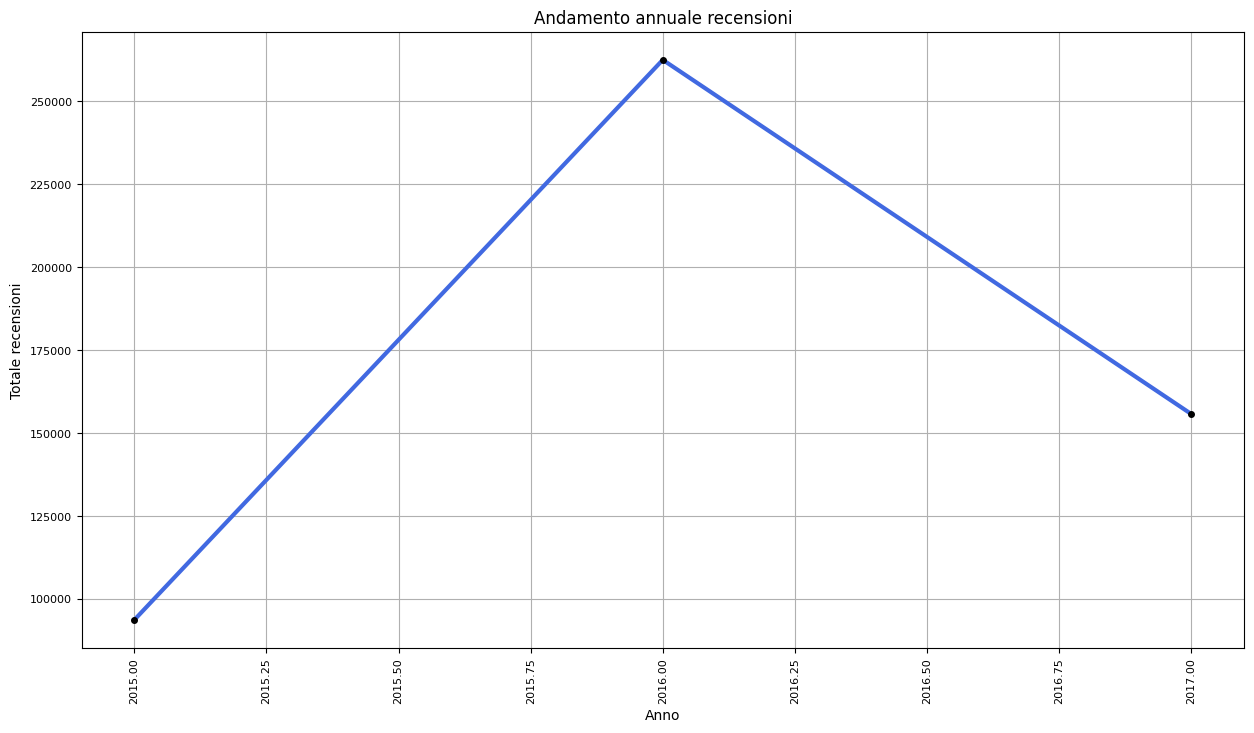

In [18]:
df_anno = dfHotelClean.groupby("year").size().reset_index(name='conteggio')

grafico_reviwes_year = df_anno.plot(
    kind='line',
    x="year",
    y="conteggio",

    figsize=(15,8),
    title='Andamento annuale recensioni',
    grid=True,
    legend=False,

    color='royalblue',
    linewidth=3,
    linestyle='solid',
    marker='o',
    markersize=4,
    markeredgecolor='black',
    markerfacecolor='black',
    markeredgewidth=1,
    alpha=1,

    rot=90,
    fontsize=8,
    xlabel='Anno',
    ylabel='Totale recensioni'
)

for i, row in df_anno.iterrows():
   grafico_reviwes_year.annotate(
        f'{row["conteggio"]}',
        (i, row['conteggio']),
        xytext=(0,10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='blue',
        fontstyle='italic',
        fontweight='bold',
    )

plt.savefig('grafico_reviews_year.png', dpi=150)

plt.show()

Il grafico a linee mostra l'evoluzione del volume totale delle recensioni raccolte nel dataset tra il 2015 e il 2017.

- **Picco del 2016:** Si osserva una crescita esponenziale nel 2016, anno in cui è stato raccolto il maggior numero di dati (oltre 250.000 recensioni).
- **Interpretazione del trend:** * Il dato del **2015** è più basso perché riflette solo una parte dell'anno (la raccolta dei dati inizia tipicamente a metà anno).
- Il calo visibile nel **2017** non indica un minor numero di viaggiatori, ma il fatto che il dataset si interrompe ad agosto 2017.
- **Volume complessivo:** L'andamento conferma che il cuore del dataset è concentrato nell'arco temporale 2016-2017, garantendo una base statistica solida per le analisi stagionali e di sentiment.


### Line plot recensioni/mese

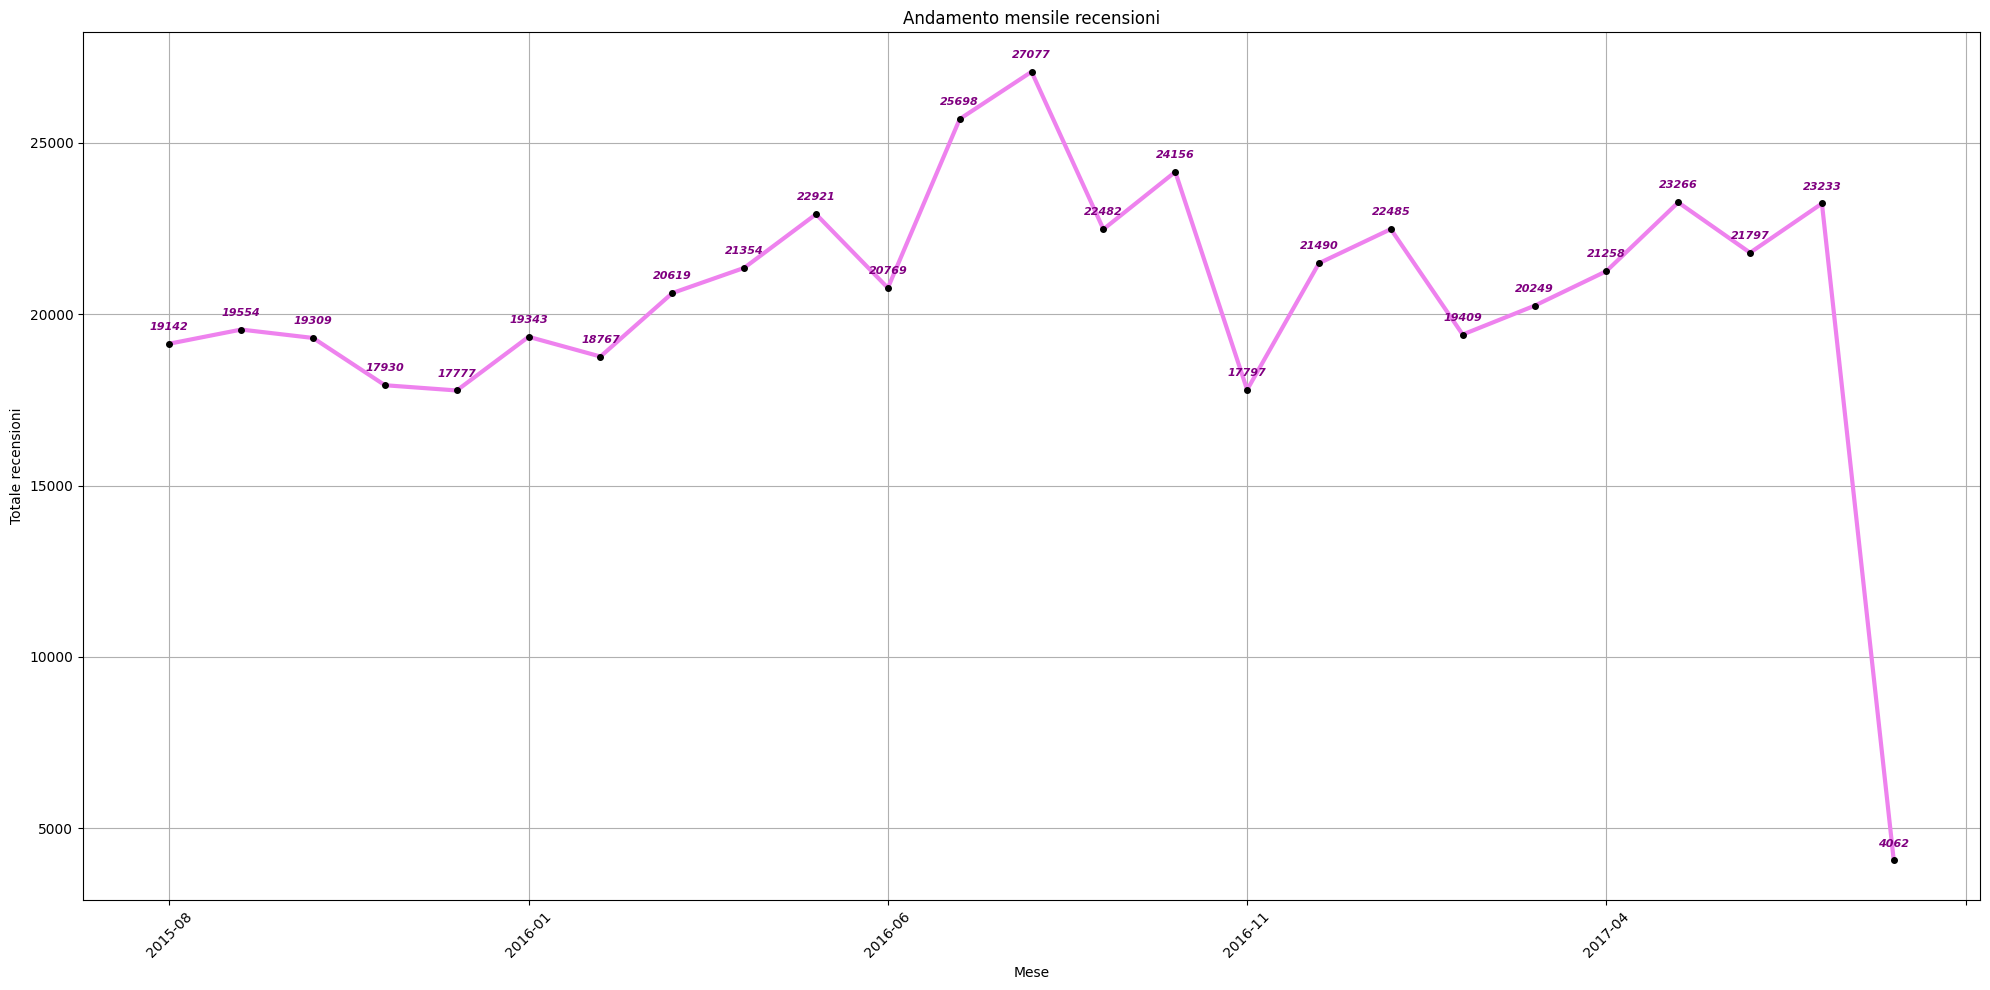

In [19]:
df_mese = dfHotelClean.groupby(["year", "month"]).size().reset_index(name='conteggio')
df_mese['periodo'] = df_mese['year'].astype(str) + "-" + df_mese['month'].astype(str).str.zfill(2)

grafico_reviwes_month = df_mese.plot(
    kind='line',
    x="periodo",
    y="conteggio",

    figsize=(20,10),
    title='Andamento mensile recensioni',
    grid=True,
    legend=False,

    color='violet',
    linewidth=3,
    linestyle='solid',
    marker='o',
    markersize=4,
    markeredgecolor='black',
    markerfacecolor='black',
    markeredgewidth=1,
    alpha=1,

    rot=45,
    fontsize=10,
    xlabel='Mese',
    ylabel='Totale recensioni'
)

for i, row in df_mese.iterrows():
    grafico_reviwes_month.annotate(
        f'{row["conteggio"]}',
        (i, row['conteggio']),
        xytext=(0,10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='purple',
        fontstyle='italic',
        fontweight='bold',
    )


plt.savefig('grafico_reviews_month.png', dpi=150)

plt.tight_layout()
plt.show()

Il grafico analizza il flusso delle recensioni su base mensile lungo tutto l'arco temporale del dataset (Agosto 2015 - Agosto 2017).

- **Picchi Stagionali:** Si nota chiaramente che i volumi più alti si registrano durante i mesi estivi. Il picco massimo assoluto si raggiunge a **Luglio 2016** (27.077 recensioni), seguito da un volume molto alto a **Maggio 2017** e **Luglio 2017**.
- **Cali Periodici:** I periodi con minor afflusso di recensioni corrispondono ai mesi autunnali e invernali (Novembre e Gennaio), con una flessione visibile a Novembre 2016 (17.797).
- **Crescita Organica:** Confrontando i mesi omologhi (es. Agosto 2015 vs Agosto 2016), si nota come il numero di recensioni sia tendenzialmente aumentato, segno di una maggiore adozione delle piattaforme di recensione o di un aumento del traffico turistico catturato nel dataset.
- **L'anomalia finale:** Il crollo verticale registrato nell'ultimo mese visualizzato (**Agosto 2017**) è dovuto al fatto che la raccolta dati si interrompe nei primi giorni del mese (solo 4.062 recensioni), non rappresentando quindi un mese completo.

#### Conclusioni sulla Stagionalità:
I dati confermano una forte componente stagionale tipica del settore hospitality europeo: il volume di feedback segue fedelmente i flussi turistici, con una concentrazione massima nel secondo e terzo trimestre dell'anno.

## 2. Bar chart top 10 nazionalità per recensioni

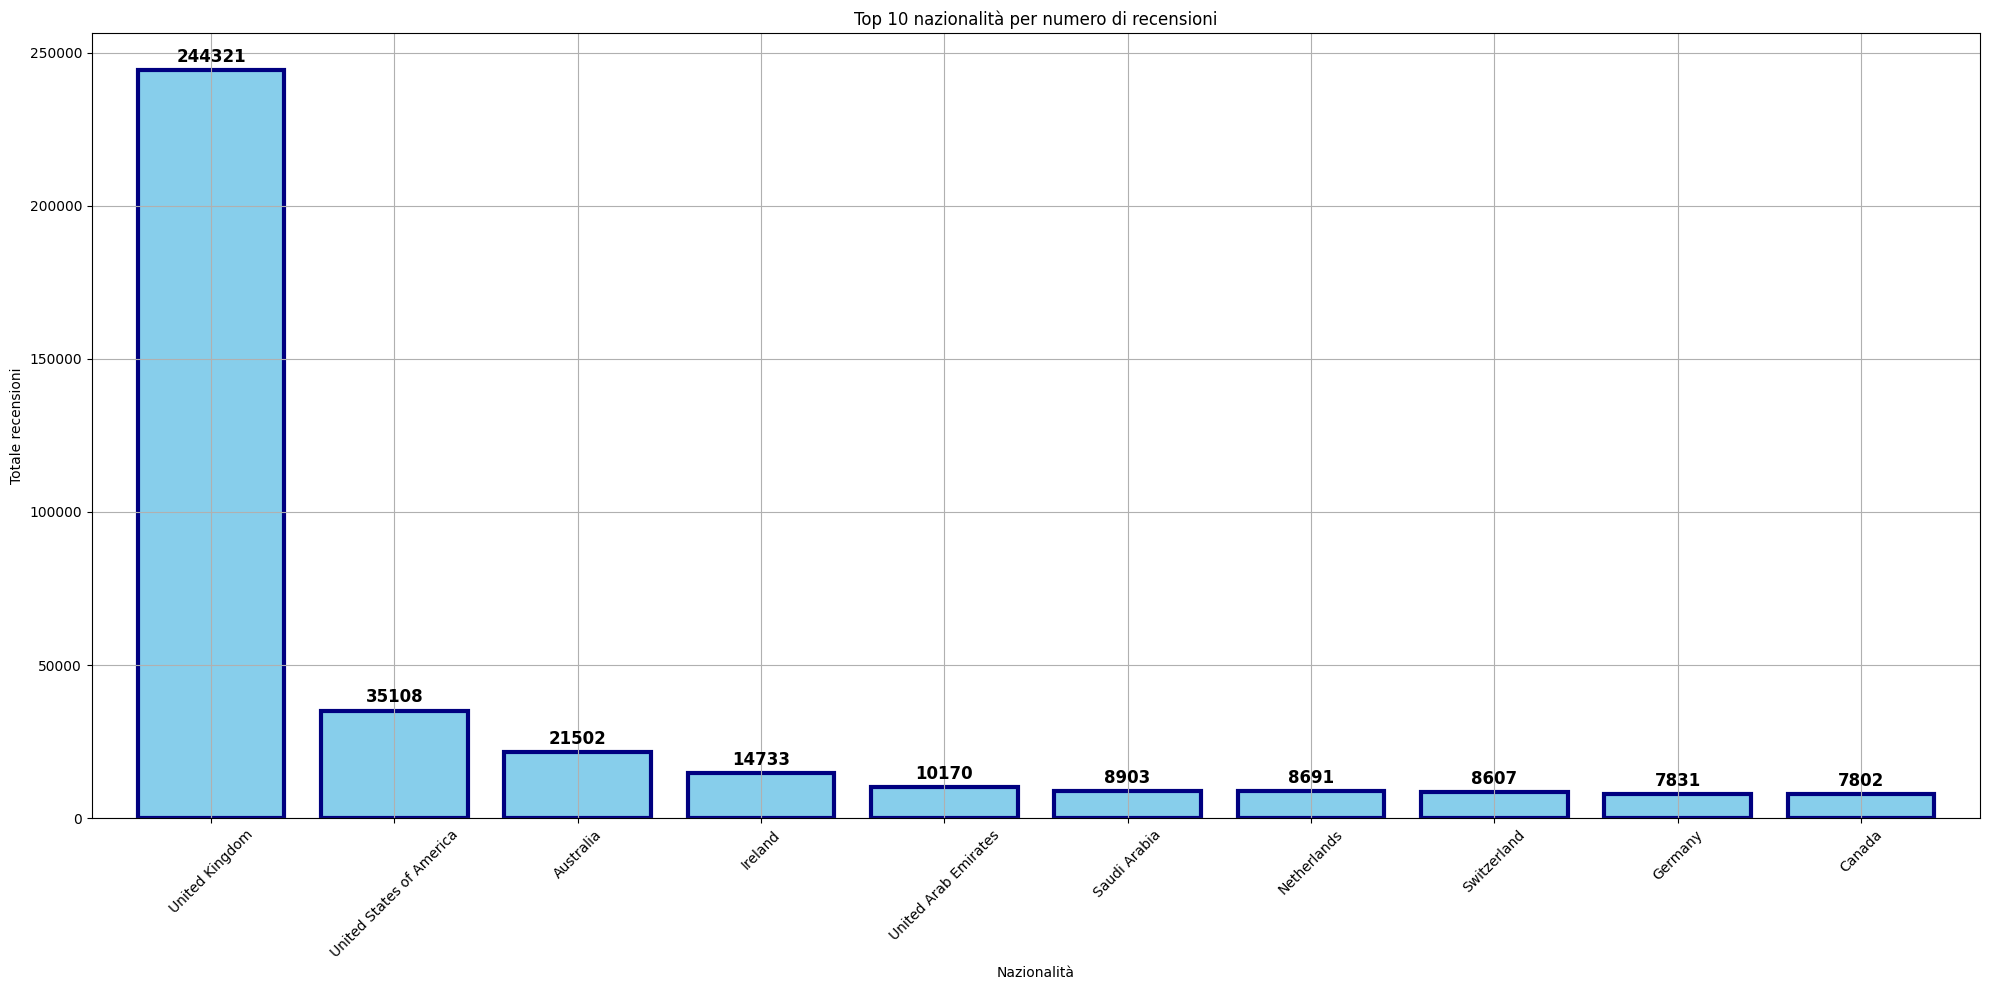

In [20]:

grafico_top_naz = top_nazionalita.plot(
    kind='bar',
    x='nazionalita',
    y='numero_recensioni',

    #ASSETTO GRAFICO
    figsize=(20,10),
    title='Top 10 nazionalità per numero di recensioni',
    grid=True,
    legend=False,

    color='skyblue',
    edgecolor='navy',
    linewidth=3,
    width=0.8,

    rot=45,
    fontsize=10,
    xlabel='Nazionalità',
    ylabel='Totale recensioni',
)

grafico_top_naz.bar_label(
    grafico_top_naz.containers[0], 
    fmt='%d', 
    label_type='edge', # Mette l'etichetta sopra il bordo della barra
    padding=3,         # Distanza dalla barra
    fontsize=12, 
    fontweight='bold',
    color='black'
)

plt.tight_layout()
plt.savefig('grafico_top_naz.png', dpi=150)
plt.show()

Il grafico a barre illustra le prime dieci nazionalità dei recensori in base al numero totale di contributi lasciati sulla piattaforma.

- **Dominio del Regno Unito:** Con ben **244.321 recensioni**, il mercato UK rappresenta la fetta più ampia del dataset.
* **Distribuzione "Long Tail":** Dopo la prima posizione, si nota un calo drastico dei volumi. Gli USA (secondi in classifica) presentano circa 35.000 recensioni, un numero significativo ma sette volte inferiore rispetto al Regno Unito.
* **Presenza Internazionale:** Oltre ai paesi europei (*Ireland, Netherlands, Germany*), figurano tra i primi dieci anche i viaggiatori provenienti dagli *Emirati Arabi Uniti* e dall'*Arabia Saudita*, evidenziando il carattere internazionale degli hotel recensiti.

## 3. Bar chart top 10 città per numero recensioni

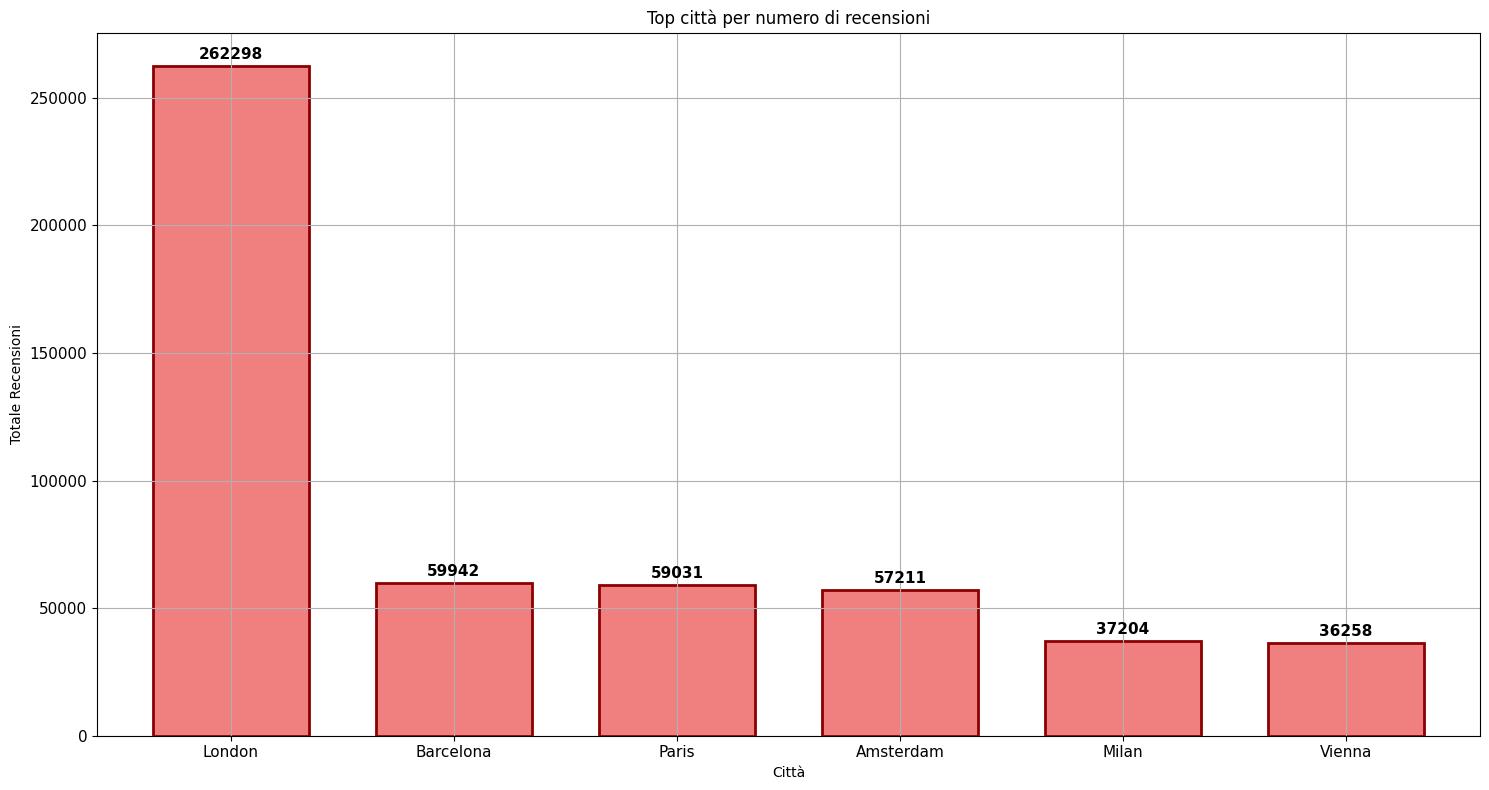

In [21]:
top_citta = distribuzione_recensioni_per_citta.sort_values(by="numero_recensioni", ascending=False).head(10)

grafico_top_citta = top_citta.plot(
    kind='bar',
    x='citta',
    y='numero_recensioni',

    figsize=(15, 8),
    title='Top città per numero di recensioni',
    grid=True,
    legend=False,

    color='lightcoral',
    edgecolor='darkred',
    linewidth=2,
    width=0.7,

    rot=0,
    fontsize=11,
    xlabel='Città',
    ylabel='Totale Recensioni'
)

grafico_top_citta.bar_label(
    grafico_top_citta.containers[0], 
    fmt='%d', 
    label_type='edge', 
    padding=3, 
    fontsize=11, 
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('grafico_top_citta.png', dpi=150)
plt.show()

Il grafico analizza le città in cui si concentra il maggior volume di recensioni, evidenziando le principali destinazioni turistiche presenti nel dataset.

- Con **262.298 recensioni**, Londra si conferma la destinazione dominante, superando di gran lunga tutte le altre città messe insieme. Questo spiega anche l'altissima percentuale di recensori britannici analizzata in precedenza.
- Le posizioni successive mostrano un equilibrio tra le grandi capitali del turismo europeo: **Barcellona, Parigi e Amsterdam** mantengono volumi simili (tra le 57.000 e le 60.000 recensioni).
- **Milano e Vienna** chiudono la classifica delle top città, con una presenza comunque significativa che sfiora i 40.000 contributi ciascuna.

## 4. Box plot distribuzione Reviewer Score per nazionalità top 3

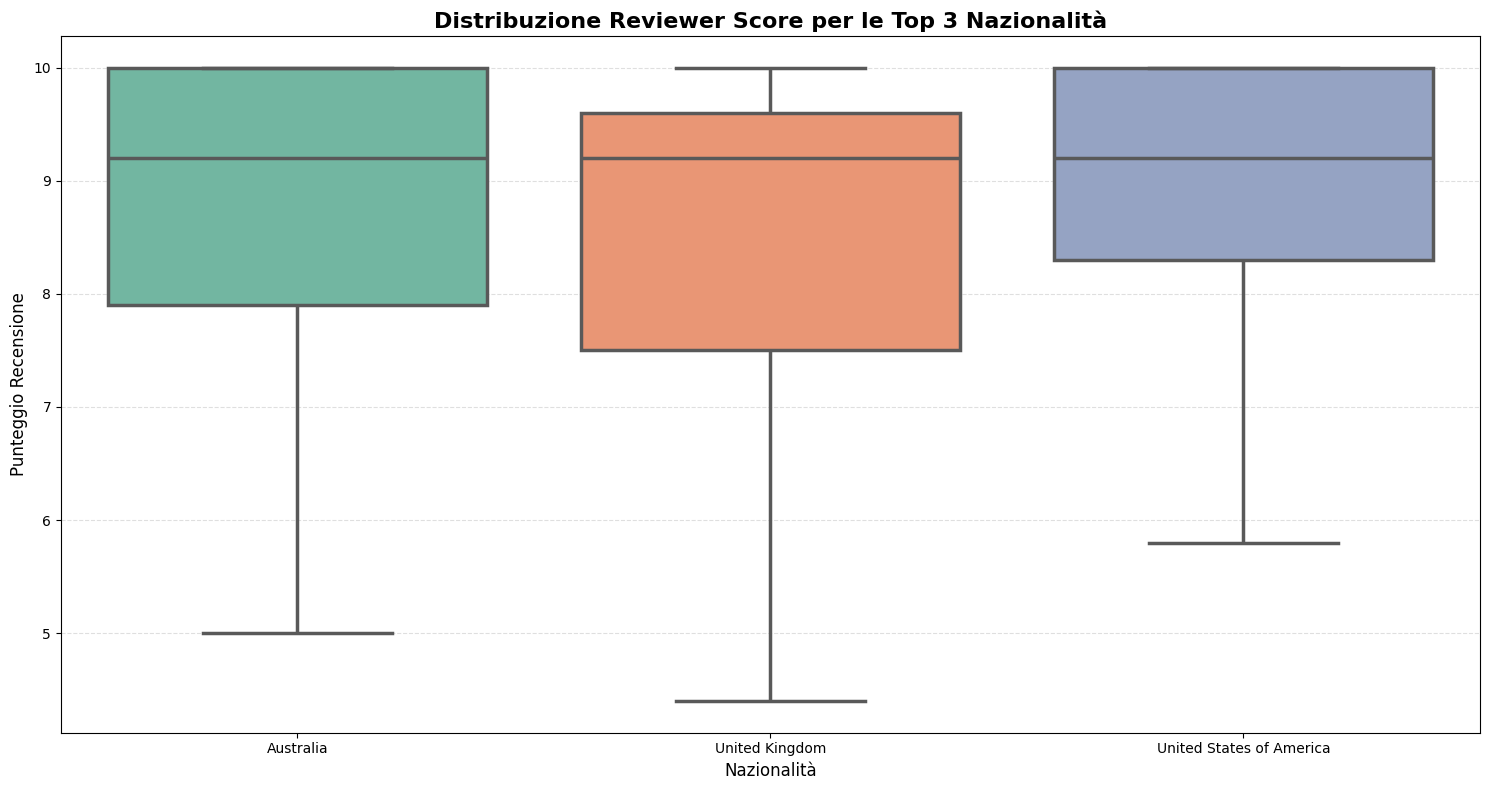

In [22]:
top3_nomi = top_nazionalita['nazionalita'].head(3).tolist()

df_top3 = dfHotelClean[dfHotelClean['reviewer_nationality'].isin(top3_nomi)]

plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df_top3, 
    x='reviewer_nationality', 
    y='reviewer_score',
    hue='reviewer_nationality',
    palette='Set2',
    legend=False,
    linewidth=2.5,
    showfliers=False
)

plt.title('Distribuzione Reviewer Score per le Top 3 Nazionalità', fontsize=16, fontweight='bold')
plt.xlabel('Nazionalità', fontsize=12)
plt.ylabel('Punteggio Recensione', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grafico_boxplot.png', dpi=150)
plt.show()

Il Box Plot permette di confrontare la distribuzione statistica dei voti assegnati dai recensori provenienti da Australia, Regno Unito e Stati Uniti.

- La linea centrale in tutti e tre i box si posiziona intorno al valore **9.2**, a conferma del fatto che la maggior parte degli utenti tende a rilasciare punteggi molto alti indipendentemente dalla nazionalità.
- I turisti degli **Stati Uniti** mostrano un box più compresso verso l'alto, indicando una maggiore concentrazione di voti eccellenti e una minore tolleranza verso i voti bassi.
- Il **Regno Unito** presenta la coda di voti più lunga verso il basso, suggerendo una presenza più marcata di recensioni critiche.
- Il "corpo" centrale della distribuzione (che contiene il 50% dei voti) si colloca per tutte le nazioni tra **7.5 e 10**, evidenziando un sentiment generale fortemente positivo verso le strutture recensite.

## 5. Histogram Review Length per categoria score

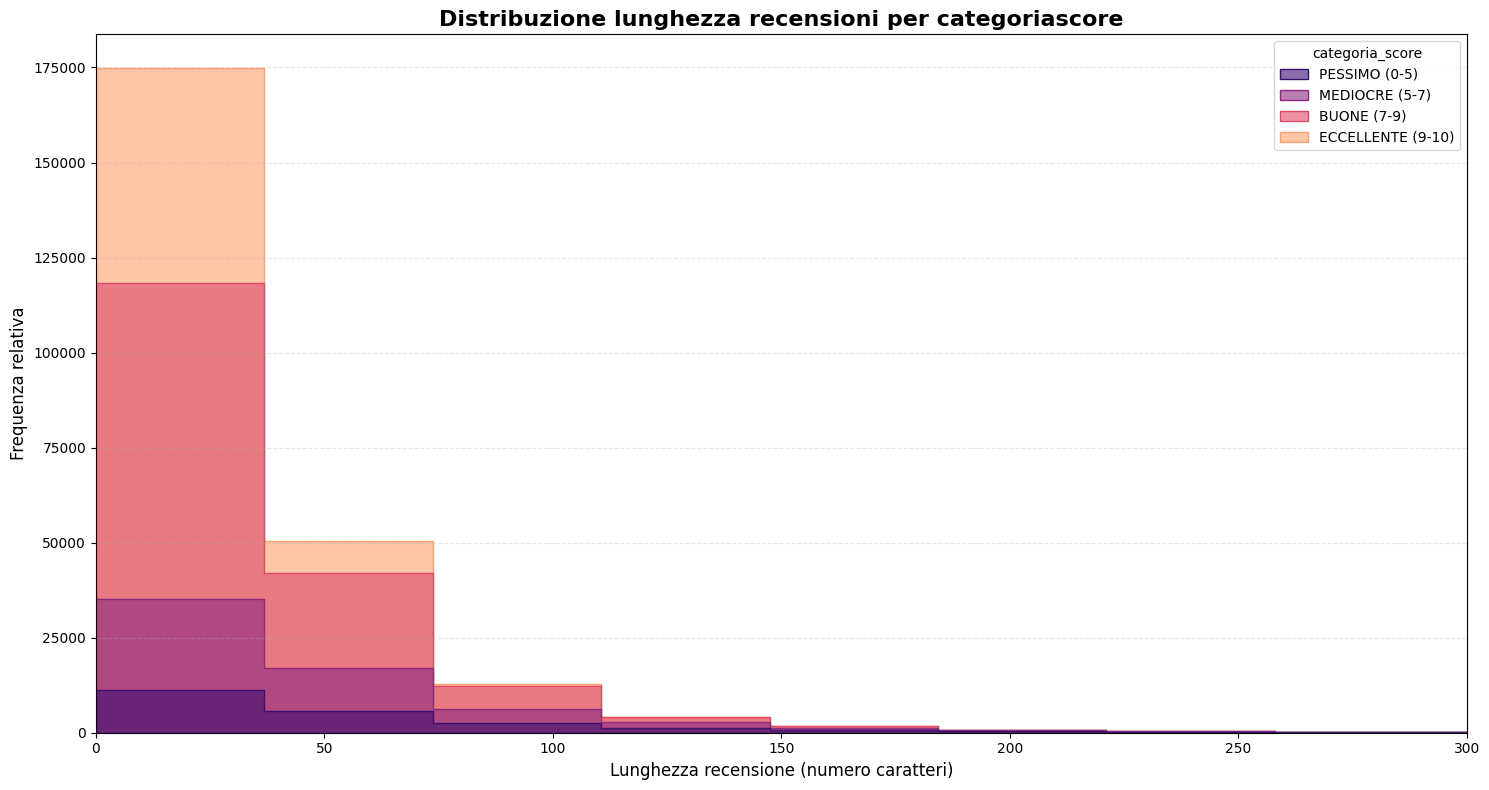

In [23]:
plt.figure(figsize=(15, 8))

sns.histplot(
    data=dfHotelClean, 
    x='review_length', 
    hue='categoria_score',
    element='step',
    palette='magma',
    common_norm=False,
    bins=20,
    alpha=0.6
)

plt.title('Distribuzione lunghezza recensioni per categoriascore', fontsize=16, fontweight='bold')
plt.xlabel('Lunghezza recensione (numero caratteri)', fontsize=12)
plt.ylabel('Frequenza relativa', fontsize=12)

plt.xlim(0, 300) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('istogramma_lunghezza_score.png', dpi=150)
plt.show()

L'istogramma visualizza la distribuzione della lunghezza del testo delle recensioni (espressa in numero di caratteri), segmentata in base alla fascia di punteggio assegnata dal recensore (*Pessimo, Mediocre, Buone, Eccellente*).

Osservazioni Chiave:
- **Predominanza delle recensioni brevi:** La stragrande maggioranza delle recensioni si concentra tra **0 e 70 caratteri**. Questo indica che i viaggiatori tendono a fornire feedback sintetici.
- **Correlazione tra voto e lunghezza:**
    - Le recensioni nella categoria **"ECCELLENTE"** (arancione) mostrano il picco più alto nelle fasce di lunghezza minime. Chi è molto soddisfatto spesso si limita a commenti brevi e positivi.
    - Le recensioni **"PESSIME"** (viola scuro) hanno una distribuzione più "piatta" e una coda più lunga. Come confermato dai dati numerici, la media caratteri per i voti bassi è significativamente più alta rispetto ai voti eccellenti.

Il grafico è stato limitato a **300 caratteri** sull'asse X per escludere gli outlier (recensioni estremamente lunghe) e permettere una migliore visualizzazione del cuore della distribuzione.

## 6. Scatter plot Review Length vs Reviewer Score (colore per nazionalità)

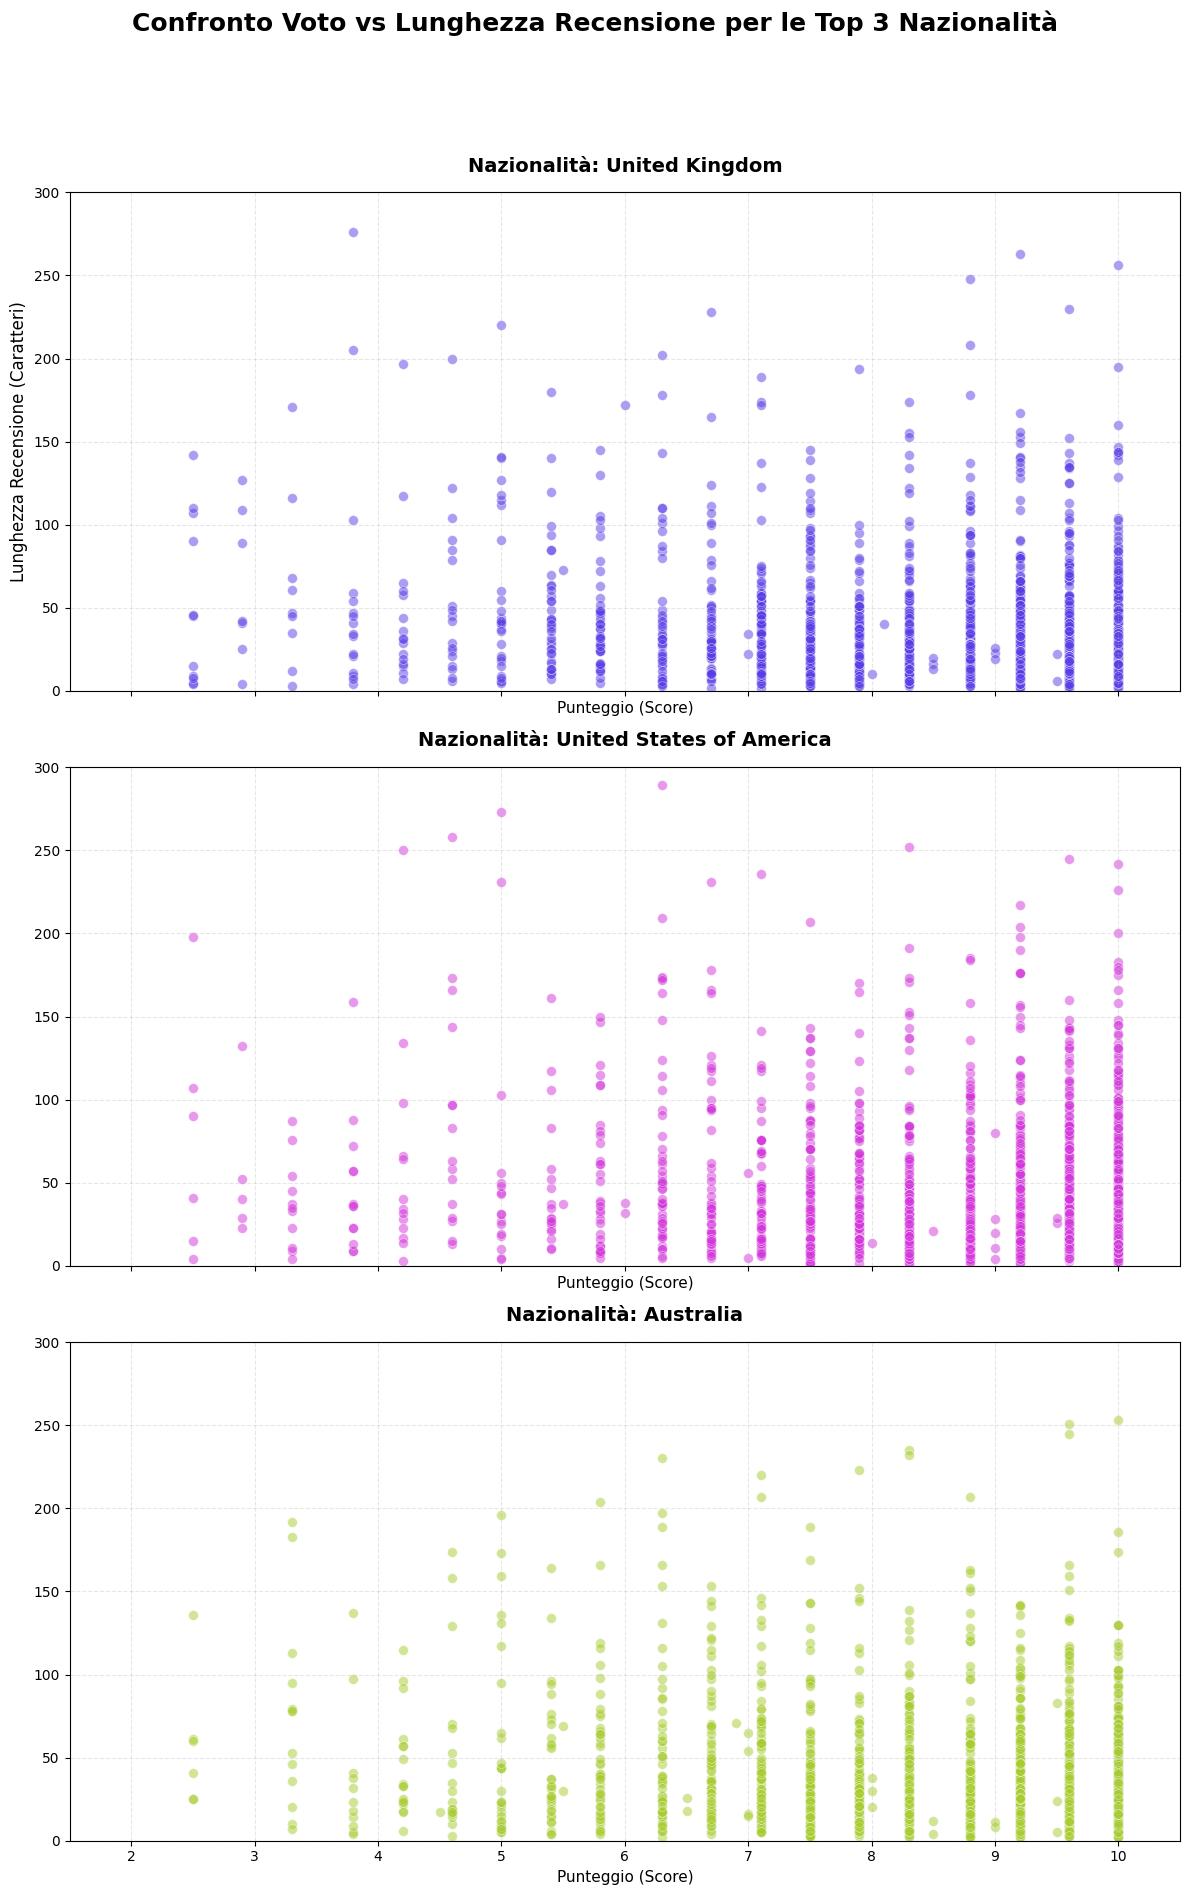

In [24]:
top3_nomi = top_nazionalita['nazionalita'].head(3).tolist()
colori = ["#593ce7", "#d334db", "#a7cc2e"]

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

for i, nazione in enumerate(top3_nomi):
    dati_nazione = dfHotelClean[dfHotelClean['reviewer_nationality'] == nazione]
    
    sample_nazione = dati_nazione.sample(n=min(2000, len(dati_nazione)), random_state=42)

    axes[i].scatter(
        sample_nazione['reviewer_score'], 
        sample_nazione['review_length'], 
        alpha=0.5, 
        c=colori[i], 
        edgecolors='white',
        linewidth=0.5,
        s=50
    )

    axes[i].set_title(f'Nazionalità: {nazione}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Punteggio (Score)', fontsize=11)
    axes[i].set_xlim(1.5, 10.5)
    axes[i].set_ylim(0, 300)
    axes[i].grid(True, linestyle='--', alpha=0.3)

axes[0].set_ylabel('Lunghezza Recensione (Caratteri)', fontsize=12)

plt.suptitle('Confronto Voto vs Lunghezza Recensione per le Top 3 Nazionalità', 
             fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('scatter_split_top3.png', dpi=150, bbox_inches='tight')
plt.show()

Attraverso l'uso di sottografici verticali, abbiamo messo a confronto il comportamento dei recensori delle tre nazionalità più rappresentate nel dataset: **United Kingdom**, **USA** e **Australia**.

Osservazioni:
- Si osserva una coerenza sorprendente tra le tre nazioni. La densità maggiore di recensioni si concentra sempre nella parte inferiore destra (punteggi tra 8 e 10 con lunghezza inferiore ai 100 caratteri).

- Le recensioni molto brevi (sotto i 50 caratteri) sono presenti in modo massiccio su tutta la scala dei punteggi, indicando una diffusa tendenza alla sintesi.
- I "picchi" verticali (recensioni oltre i 200 caratteri) sono più frequenti quando il punteggio è basso o medio (2-6). Questo conferma visivamente che gli utenti tendono a scrivere di più per giustificare un'esperienza negativa.

- Il gruppo **United Kingdom** mostra una massa critica di dati superiore (essendo il mercato principale), ma la forma della "nuvola" è speculare a quella di **USA** e **Australia**.
- Non emergono differenze culturali significative: il modo in cui il punteggio influenza la lunghezza del testo scritto è un tratto universale nel campione analizzato.

## 7. Bar chart score medio per top 10 città

C:\Users\user\AppData\Local\Temp\ipykernel_10156\592221628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


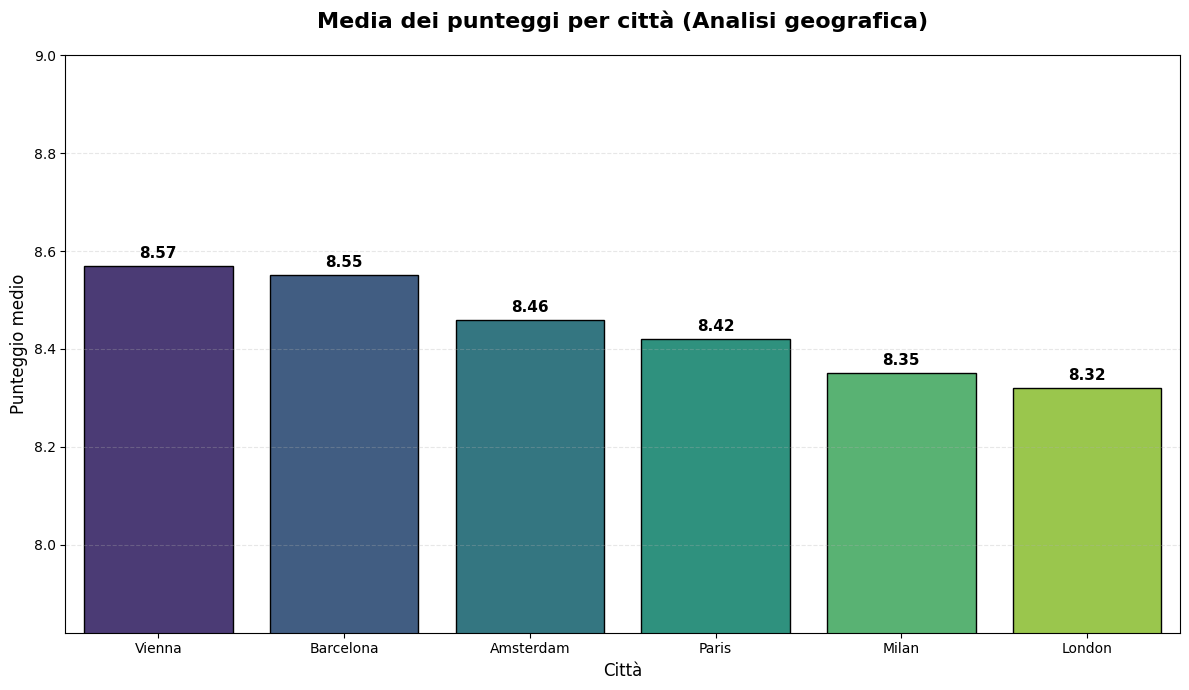

In [25]:
df_plot = analisi_geografica.sort_values(by="punteggio_medio", ascending=False)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=df_plot, 
    x='hotel_city', 
    y='punteggio_medio', 
    palette='viridis',
    edgecolor='black'
)

plt.title('Media dei punteggi per città (Analisi geografica)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Città', fontsize=12)
plt.ylabel('Punteggio medio', fontsize=12)

plt.ylim(min(df_plot['punteggio_medio']) - 0.5, 9) 

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("bar_chart_score_medio.png", dpi=300, bbox_inches='tight')
plt.show()

Attraverso l'aggregazione dei dati per area geografica, abbiamo isolato il punteggio medio assegnato dagli utenti nelle diverse città per valutare la qualità dell'offerta alberghiera locale.

- **Vienna** guida la classifica con una media di **8.57**, posizionandosi come la destinazione con il più alto indice di gradimento tra quelle analizzate.
- **Barcellona (8.55)** e **Amsterdam (8.46)** seguono a breve distanza, confermando standard qualitativi molto elevati e costanti.
- **Londra (8.32)** e **Parigi (8.42)**, nonostante i volumi di recensioni estremamente più elevati che solitamente portano a una maggiore dispersione dei voti, riescono a mantenere una media solida sopra l'8.0.
- Il range ristretto tra la prima e l'ultima posizione (solo 0.25 punti di scarto) indica che il dataset si focalizza su strutture di livello medio-alto distribuite in modo uniforme nelle principali capitali europee.

L'asse delle ordinate è stato limitato all'intervallo [7.8 - 9.0] per evidenziare le micro-differenze statistiche tra le città, che altrimenti risulterebbero appiattite.

## 8. Heatmap correlazioni numeriche (score, word counts, days since review)

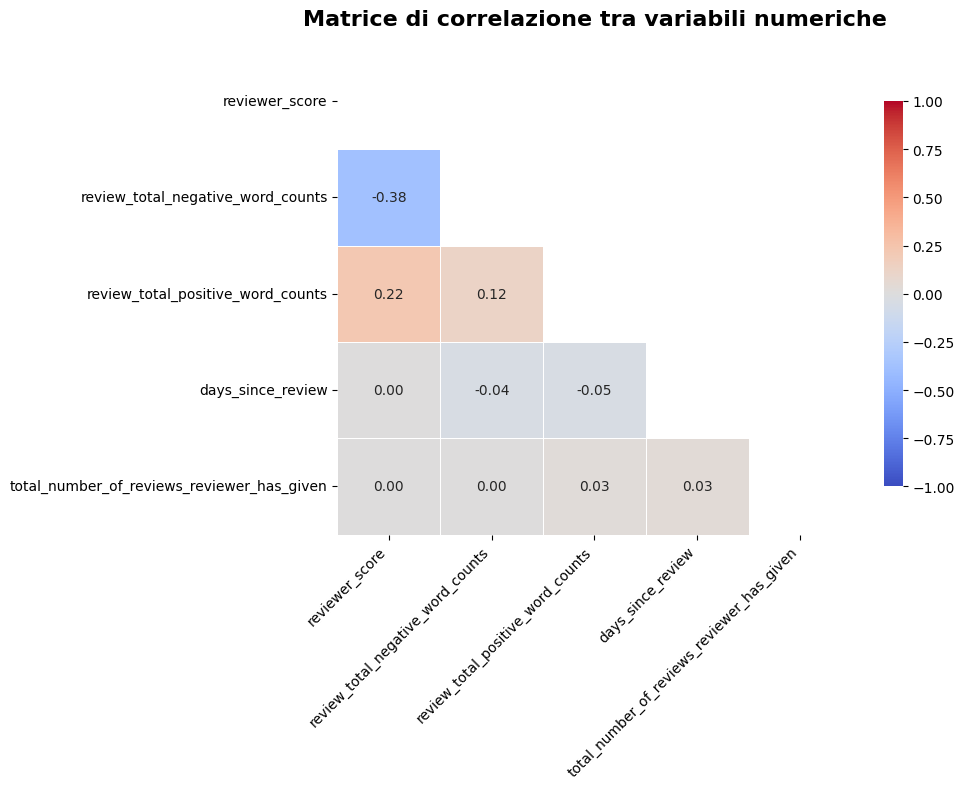

In [26]:
colonne_corr = [
    'reviewer_score', 
    'review_total_negative_word_counts', 
    'review_total_positive_word_counts', 
    'days_since_review', 
    'total_number_of_reviews_reviewer_has_given'
]

corr_matrix = dfHotelClean[colonne_corr].corr()

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matrice di correlazione tra variabili numeriche', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("heatmap_correlazioni_numeriche.png", dpi=300, bbox_inches='tight')
plt.show()

L'analisi finale esplora le relazioni statistiche tra le diverse metriche numeriche del dataset per identificare eventuali dipendenze tra il comportamento degli utenti e i punteggi assegnati.

- Emerge una **correlazione negativa (-0.38)** tra il punteggio del recensore e il numero di parole negative. Questo dato è il più significativo della matrice: conferma che i voti bassi non sono casuali, ma sono sistematicamente accompagnati da spiegazioni testuali più lunghe e dettagliate.
- La relazione tra score e parole positive è presente ma più debole (**0.22**), suggerendo che un cliente soddisfatto tende a lasciare un voto alto anche senza scrivere necessariamente testi molto lunghi.
- La variabile `days_since_review` ha una correlazione nulla (**0.00**) con lo score, indicando che la qualità percepita è rimasta stabile nel tempo.
- Il numero di recensioni fornite in precedenza dall'utente non influisce sul voto finale, escludendo bias legati all' "esperienza" del recensore.


## Conclusioni Finali

Il progetto di analisi ha permesso di delineare un profilo chiaro dell'ecosistema alberghiero rappresentato nel dataset:

1.  **Geografia:** Il mercato è dominato da **Londra** e da viaggiatori del **Regno Unito**, che rappresentano la base statistica principale.
2.  **Qualità:** Nonostante i grandi volumi, città come **Vienna** e **Barcellona** spiccano per la media voti più elevata, mantenendo uno standard di eccellenza.
3.  **Comportamento:** Gli utenti sono mediamente molto soddisfatti (mediana voti > 9), ma diventano molto più analitici e prolissi nel descrivere i disservizi rispetto ai punti di forza.
4.  **Stagionalità:** Il flusso delle recensioni segue i picchi del turismo europeo, con una concentrazione massima nel periodo estivo.